In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv('fake_news_dataset.csv')
print('Dataset shape:', df.shape)
display(df.head())
print(df['Label'].value_counts())


Dataset shape: (50, 4)


,Article_ID,Title,Content,Label
0,N001,Government launches new scholarship program fo...,The education ministry announced a new scholar...,REAL
1,N002,Scientists confirm drinking coffee makes every...,A viral article claims scientists have proven ...,FAKE
2,N003,City opens new public library with digital lea...,The city administration inaugurated a public l...,REAL
3,N004,NASA discovers a giant city on the dark side o...,A social media post claims NASA discovered a s...,FAKE
4,N005,University introduces new data science laboratory,The university announced a data science labora...,REAL


Label
REAL    25
FAKE    25
Name: count, dtype: int64


In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Text'] = (df['Title'] + ' ' + df['Content']).apply(preprocess_text)
display(df[['Title','Cleaned_Text','Label']].head())


,Title,Cleaned_Text,Label
0,Government launches new scholarship program fo...,government launches new scholarship program fo...,REAL
1,Scientists confirm drinking coffee makes every...,scientists confirm drinking coffee makes every...,FAKE
2,City opens new public library with digital lea...,city opens new public library with digital lea...,REAL
3,NASA discovers a giant city on the dark side o...,nasa discovers a giant city on the dark side o...,FAKE
4,University introduces new data science laboratory,university introduces new data science laborat...,REAL


In [4]:
X_train, X_test, y_train, y_test = train_test_split(df['Cleaned_Text'], df['Label'], test_size=0.20, random_state=42, stratify=df['Label'])
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print('Training articles:', len(X_train))
print('Testing articles:', len(X_test))


Training articles: 40
Testing articles: 10


In [5]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
print('Model training completed!')


Model training completed!


In [6]:
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy*100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.83      1.00      0.91         5
        REAL       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



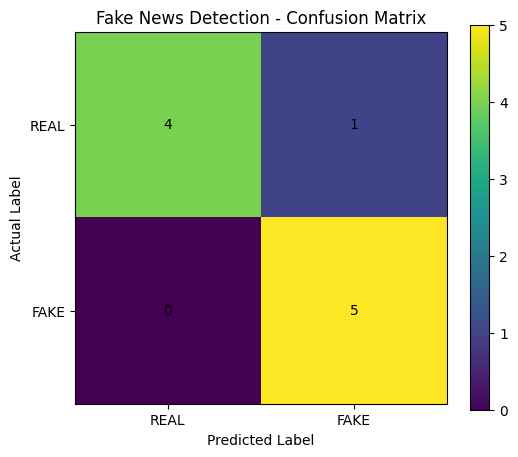

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=['REAL','FAKE'])
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title('Fake News Detection - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0,1],['REAL','FAKE'])
plt.yticks([0,1],['REAL','FAKE'])
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha='center',va='center')
plt.show()


In [8]:
new_articles = [
    'The education department announced a new scholarship program for eligible students.',
    'A viral website claims one ordinary fruit gives every person unlimited energy forever.',
    'The city hospital opened a new emergency care unit with additional medical staff.'
]
new_cleaned = [preprocess_text(x) for x in new_articles]
new_tfidf = vectorizer.transform(new_cleaned)
predictions = model.predict(new_tfidf)
for article, prediction in zip(new_articles, predictions):
    print('\nArticle:', article)
    print('Predicted:', prediction)



Article: The education department announced a new scholarship program for eligible students.
Predicted: REAL

Article: A viral website claims one ordinary fruit gives every person unlimited energy forever.
Predicted: FAKE

Article: The city hospital opened a new emergency care unit with additional medical staff.
Predicted: REAL


In [9]:
print('='*55)
print('FAKE NEWS DETECTION ANALYTICAL REPORT')
print('='*55)
print('Total articles:', len(df))
print('\nLabel distribution:')
print(df['Label'].value_counts())
print(f'\nModel accuracy: {accuracy*100:.2f}%')
print('\nMethod: TF-IDF + Multinomial Naive Bayes')
print('\nConclusion: This NLP model can screen news articles as REAL or FAKE based on learned text patterns. It should be used as a screening aid, not as a substitute for professional fact-checking.')


FAKE NEWS DETECTION ANALYTICAL REPORT
Total articles: 50

Label distribution:
Label
REAL    25
FAKE    25
Name: count, dtype: int64

Model accuracy: 90.00%

Method: TF-IDF + Multinomial Naive Bayes

Conclusion: This NLP model can screen news articles as REAL or FAKE based on learned text patterns. It should be used as a screening aid, not as a substitute for professional fact-checking.


In [10]:
df.to_csv('fake_news_analysis_results.csv', index=False)
print('Saved: fake_news_analysis_results.csv')


Saved: fake_news_analysis_results.csv
